# DSA210 — Does Transfer Spending Buy Success in La Liga?
**Alp Erdal Çetinalp — 35795**

This notebook covers Stage 1 of the project: data collection, exploratory data analysis, and hypothesis testing.

The main question is simple: do clubs that spend more in the transfer market actually finish higher in the table?


## 1. Setup

## AI Usage Disclosure
Claude (claude.ai) was used to assist in writing parts of the code in this notebook. All project ideas, data decisions, and analysis interpretation are my own.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import requests
from io import StringIO
import time
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('muted')

print("All libraries loaded.")


All libraries loaded.


In [25]:
import os
os.makedirs('data', exist_ok=True)
print("data/ folder ready")

data/ folder ready


## 2. Transfer Data

The transfer records come from [d2ski/football-transfers-data](https://github.com/d2ski/football-transfers-data),
which scraped Transfermarkt for all major European leagues from 2009 to 2021.
We filter for La Liga (league code `ES1`) and focus on permanent transfers with actual fees
— loans and free transfers are excluded from the spend calculation.


In [26]:
# Load directly from GitHub
url = "https://raw.githubusercontent.com/d2ski/football-transfers-data/master/dataset/transfers.csv"
df_raw = pd.read_csv(url, low_memory=False)

print(f"Total rows in dataset: {len(df_raw):,}")
print(f"Leagues available: {df_raw['league'].unique()}")
print(f"Seasons available: {sorted(df_raw['season'].unique())}")


Total rows in dataset: 70,006
Leagues available: ['GB1' 'ES1' 'IT1' 'L1' 'FR1' 'PO1' 'NL1']
Seasons available: [np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [27]:
# Filter for La Liga only
df = df_raw[df_raw['league'] == 'ES1'].copy()
print(f"La Liga rows: {len(df):,}")
print(f"\nSample:")
df.head(3)


La Liga rows: 8,704

Sample:


,league,season,window,team_id,team_name,team_country,dir,player_id,player_name,player_age,...,counter_team_id,counter_team_name,counter_team_country,transfer_fee_amnt,market_val_amnt,is_free,is_loan,is_loan_end,is_retired,transfer_id
11161,ES1,2009,s,630,Racing Santander,Spain,in,15981,Álex Geijo,27.0,...,3368,Levante UD,Spain,2500000.0,NaN,False,False,False,False,325384
11162,ES1,2009,s,630,Racing Santander,Spain,in,38266,Marc Torrejón,23.0,...,714,RCD Espanyol Barcelona,Spain,1500000.0,NaN,False,False,False,False,320108
11163,ES1,2009,s,630,Racing Santander,Spain,in,39907,Pape Diop,23.0,...,5648,Gimnàstic de Tarragona,Spain,1200000.0,400000.0,False,False,False,False,323900


In [28]:
# Convert boolean-ish columns just in case
for col in ['is_loan', 'is_free']:
    if df[col].dtype == object:
        df[col] = df[col].map({'True': True, 'False': False, True: True, False: False})

# Incoming transfers with actual fees paid
incoming = df[
    (df['dir'] == 'in') &
    (df['is_loan'] == False) &
    (df['is_free'] == False) &
    (df['transfer_fee_amnt'].notna()) &
    (df['transfer_fee_amnt'] > 0)
]

# Outgoing transfers with actual fees received
outgoing = df[
    (df['dir'] == 'left') &
    (df['is_loan'] == False) &
    (df['is_free'] == False) &
    (df['transfer_fee_amnt'].notna()) &
    (df['transfer_fee_amnt'] > 0)
]

# Aggregate per club per season
spent = (incoming
    .groupby(['team_name', 'season'])['transfer_fee_amnt']
    .sum()
    .reset_index()
    .rename(columns={'team_name': 'team', 'transfer_fee_amnt': 'spent'}))

received = (outgoing
    .groupby(['team_name', 'season'])['transfer_fee_amnt']
    .sum()
    .reset_index()
    .rename(columns={'team_name': 'team', 'transfer_fee_amnt': 'received'}))

# Merge and compute net spend (in millions EUR)
transfers = pd.merge(spent, received, on=['team', 'season'], how='outer').fillna(0)
transfers['net_spend_m'] = (transfers['spent'] - transfers['received']) / 1e6
transfers['season_str'] = transfers['season'].astype(int).apply(lambda x: f"{x}-{x+1}")

print(f"Club-season observations in transfer data: {len(transfers)}")
transfers.sort_values('net_spend_m', ascending=False).head(10)


Club-season observations in transfer data: 251


,team,season,spent,received,net_spend_m,season_str
170,Real Madrid,2019,353500000.0,131500000.0,222.00,2019-2020
160,Real Madrid,2009,258500000.0,88500000.0,170.00,2009-2010
76,FC Barcelona,2019,301000000.0,140400000.0,160.60,2019-2020
74,FC Barcelona,2017,375100000.0,231500000.0,143.60,2017-2018
19,Atlético de Madrid,2018,149500000.0,51000000.0,98.50,2018-2019
232,Valencia CF,2015,143500000.0,50000000.0,93.50,2015-2016
66,FC Barcelona,2009,113500000.0,22000000.0,91.50,2009-2010
73,FC Barcelona,2016,124750000.0,33300000.0,91.45,2016-2017
71,FC Barcelona,2014,166720000.0,78800000.0,87.92,2014-2015
161,Real Madrid,2010,89000000.0,10500000.0,78.50,2010-2011


## 3. Performance Data (FBref)

Team-level statistics are scraped from [FBref.com](https://fbref.com) for the seasons where
transfer data is available. FBref has xG data for La Liga from 2017-18 onwards;
for earlier seasons we collect basic stats (points, goals).


In [29]:
def scrape_fbref_season(season_str):
    """
    Scrapes La Liga standings from FBref for a given season string like '2018-2019'.
    Returns a DataFrame with team, pts, w, d, l, gf, ga, and xg/xga if available.
    """
    url = f"https://fbref.com/en/comps/12/{season_str}/{season_str}-La-Liga-Stats"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) '
                      'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36'
    }
    try:
        resp = requests.get(url, headers=headers, timeout=20)
        if resp.status_code != 200:
            print(f"  HTTP {resp.status_code} for {season_str}")
            return None

        tables = pd.read_html(StringIO(resp.text))

        for table in tables:
            # Flatten multi-index columns if present
            if isinstance(table.columns, pd.MultiIndex):
                table.columns = [' '.join(str(c) for c in col).strip() for col in table.columns]

            col_lower = {str(c).strip().lower(): str(c).strip() for c in table.columns}

            if 'pts' not in col_lower or 'squad' not in col_lower:
                continue

            squad_col = col_lower['squad']
            pts_col   = col_lower['pts']

            result = table[[squad_col, pts_col]].copy()
            result.columns = ['team', 'pts']
            result = result[result['team'].notna() & (result['team'] != 'Squad')].copy()
            result['pts'] = pd.to_numeric(result['pts'], errors='coerce')
            result = result.dropna(subset=['pts'])

            # Optional extra stats
            for stat, key in [('W','w'), ('D','d'), ('L','l'), ('GF','gf'), ('GA','ga')]:
                if stat in col_lower:
                    result[key] = pd.to_numeric(
                        table[col_lower[stat]].values[:len(result)], errors='coerce')

            # xG columns — naming varies across seasons
            xg_candidates  = [c for c in table.columns
                               if 'xg' in c.lower() and 'against' not in c.lower()
                               and 'xa' not in c.lower() and 'npxg' not in c.lower()]
            xga_candidates = [c for c in table.columns
                               if ('xga' in c.lower()) or
                                  ('xg' in c.lower() and 'against' in c.lower())]

            if xg_candidates:
                result['xg'] = pd.to_numeric(
                    table[xg_candidates[0]].values[:len(result)], errors='coerce')
            if xga_candidates:
                result['xga'] = pd.to_numeric(
                    table[xga_candidates[0]].values[:len(result)], errors='coerce')

            result['season'] = season_str
            return result

    except Exception as e:
        print(f"  Error on {season_str}: {e}")
    return None


In [30]:
def get_laliga_standings(season_str):
    """
    Downloads La Liga match results from football-data.co.uk
    and computes the final standings (pts, gf, ga, w, d, l).
    season_str format: '2014-2015'
    """
    start, end = season_str.split('-')
    code = start[2:] + end[2:]  # e.g. '2014-2015' → '1415'
    url = f"https://www.football-data.co.uk/mmz4281/{code}/SP1.csv"

    try:
        df = pd.read_csv(url)
    except Exception as e:
        print(f"  Failed to download {season_str}: {e}")
        return None

    records = []
    for _, row in df.iterrows():
        try:
            ftr = row['FTR']  # H, D, A
            home = row['HomeTeam']
            away = row['AwayTeam']
            hg = int(row['FTHG'])
            ag = int(row['FTAG'])
        except:
            continue

        if ftr == 'H':
            h_pts, a_pts = 3, 0
        elif ftr == 'D':
            h_pts, a_pts = 1, 1
        else:
            h_pts, a_pts = 0, 3

        records.append({'team': home, 'pts': h_pts, 'gf': hg, 'ga': ag,
                        'w': 1 if ftr=='H' else 0,
                        'd': 1 if ftr=='D' else 0,
                        'l': 1 if ftr=='A' else 0})
        records.append({'team': away, 'pts': a_pts, 'gf': ag, 'ga': hg,
                        'w': 1 if ftr=='A' else 0,
                        'd': 1 if ftr=='D' else 0,
                        'l': 1 if ftr=='H' else 0})

    standings = (pd.DataFrame(records)
                 .groupby('team')
                 .sum()
                 .reset_index())
    standings['season'] = season_str
    return standings

# Download all seasons
seasons_to_scrape = [
    '2014-2015', '2015-2016', '2016-2017',
    '2017-2018', '2018-2019', '2019-2020', '2020-2021'
]

standings_list = []
for s in seasons_to_scrape:
    print(f"Downloading {s} ...", end=' ')
    result = get_laliga_standings(s)
    if result is not None:
        standings_list.append(result)
        print(f"OK ({len(result)} clubs)")
    else:
        print("FAILED")

standings = pd.concat(standings_list, ignore_index=True)
print(f"\nTotal standings rows: {len(standings)}")
standings.head()


Total standings rows: 140


,team,pts,gf,ga,w,d,l,season
0,Almeria,32,35,64,8,8,22,2014-2015
1,Ath Bilbao,55,42,41,15,10,13,2014-2015
2,Ath Madrid,78,67,29,23,9,6,2014-2015
3,Barcelona,94,110,21,30,4,4,2014-2015
4,Celta,51,47,44,13,12,13,2014-2015


## 4. Merging the Datasets

Transfermarkt and FBref use slightly different club name conventions.
We normalize both to a common form before merging.


In [31]:
def normalize_name(name):
    """
    Lowercase, strip, remove common suffixes to make matching more robust.
    """
    if pd.isna(name):
        return ''
    name = str(name).lower().strip()
    for suffix in [' cf', ' fc', ' sd', ' ud', ' rc', ' cd', ' sc',
                   ' de fútbol', ' balompié', ' de la coruña']:
        name = name.replace(suffix, '')
    name = name.replace('á', 'a').replace('é', 'e').replace('í', 'i')                .replace('ó', 'o').replace('ú', 'u').replace('ü', 'u')                .replace('ñ', 'n')
    name = name.strip()
    return name

# Known manual overrides after normalization
manual_map = {
    'athletic club': 'athletic bilbao',
    'athletic': 'athletic bilbao',
    'club atletico de madrid': 'atletico madrid',
    'atletico de madrid': 'atletico madrid',
    'real betis': 'betis',
    'rayo vallecano de madrid': 'rayo vallecano',
    'deportivo de la coruna': 'deportivo la coruna',
    'deportivo la coruna': 'deportivo la coruna',
    'granada cf': 'granada',
    'rc celta de vigo': 'celta vigo',
    'celta de vigo': 'celta vigo',
    'cadiz': 'cadiz',
    'real sociedad de futbol': 'real sociedad',
    'levante': 'levante',
    'malaga': 'malaga',
    'espanol': 'espanyol',
    'rcd espanyol de barcelona': 'espanyol',
    'ud almeria': 'almeria',
    'real madrid cf': 'real madrid',
    'fc barcelona': 'barcelona',
}

def clean_name(name):
    n = normalize_name(name)
    return manual_map.get(n, n)

transfers['team_clean']  = transfers['team'].apply(clean_name)
standings['team_clean']  = standings['team'].apply(clean_name)

# Preview what the cleaned names look like
print("Transfer data team names (sample):")
print(sorted(transfers['team_clean'].unique())[:15])
print("\nFBref team names (sample):")
print(sorted(standings['team_clean'].unique())[:15])


Transfer data team names (sample):
['almeria', 'athletic bilbao', 'atletico madrid', 'barcelona', 'betis', 'ca osasuna', 'cadiz', 'cd leganes', 'cd tenerife', 'celta vigo', 'cordoba', 'deportivo', 'deportivo alaves', 'elche', 'getafe']

FBref team names (sample):
['alaves', 'almeria', 'ath bilbao', 'ath madrid', 'barcelona', 'betis', 'cadiz', 'celta', 'cordoba', 'eibar', 'elche', 'espanyol', 'getafe', 'girona', 'granada']


In [32]:
# Merge on cleaned name + season string
df_merged = pd.merge(
    standings,
    transfers[['team_clean', 'season_str', 'net_spend_m', 'spent', 'received']],
    left_on=['team_clean', 'season'],
    right_on=['team_clean', 'season_str'],
    how='left'
)

# Clubs with no transfer activity in a season had net spend = 0
df_merged['net_spend_m'] = df_merged['net_spend_m'].fillna(0)
df_merged['spent']       = df_merged['spent'].fillna(0) / 1e6
df_merged['received']    = df_merged['received'].fillna(0) / 1e6

# Drop any rows where pts is null (header rows, etc.)
df_merged = df_merged.dropna(subset=['pts']).reset_index(drop=True)

print(f"Final merged dataset: {len(df_merged)} club-season observations")
print(f"Seasons covered: {sorted(df_merged['season'].unique())}")
print(f"\nMissing values:")
print(df_merged.isnull().sum())
df_merged.head(10)


Final merged dataset: 140 club-season observations
Seasons covered: ['2014-2015', '2015-2016', '2016-2017', '2017-2018', '2018-2019', '2019-2020', '2020-2021']

Missing values:
team            0
pts             0
gf              0
ga              0
w               0
d               0
l               0
season          0
team_clean      0
season_str     71
net_spend_m     0
spent           0
received        0
dtype: int64


,team,pts,gf,ga,w,d,l,season,team_clean,season_str,net_spend_m,spent,received
0,Almeria,32,35,64,8,8,22,2014-2015,almeria,2014-2015,-3.00,0.00,3.0
1,Ath Bilbao,55,42,41,15,10,13,2014-2015,ath bilbao,NaN,0.00,0.00,0.0
2,Ath Madrid,78,67,29,23,9,6,2014-2015,ath madrid,NaN,0.00,0.00,0.0
3,Barcelona,94,110,21,30,4,4,2014-2015,barcelona,2014-2015,87.92,166.72,78.8
4,Celta,51,47,44,13,12,13,2014-2015,celta,NaN,0.00,0.00,0.0
5,Cordoba,20,22,68,3,11,24,2014-2015,cordoba,2014-2015,0.25,0.25,0.0
6,Eibar,35,34,55,9,8,21,2014-2015,eibar,NaN,0.00,0.00,0.0
7,Elche,41,35,62,11,8,19,2014-2015,elche,2014-2015,-6.00,0.00,6.0
8,Espanol,49,47,51,13,10,15,2014-2015,espanyol,NaN,0.00,0.00,0.0
9,Getafe,37,33,64,10,7,21,2014-2015,getafe,2014-2015,-8.00,0.00,8.0


In [33]:
# Save the merged dataset for reference
df_merged.to_csv('data/la_liga_merged.csv', index=False)
print("Saved to data/la_liga_merged.csv")


Saved to data/la_liga_merged.csv


In [34]:
# Compute additional on-pitch performance metrics
df_merged['games']    = df_merged['w'] + df_merged['d'] + df_merged['l']
df_merged['gd']       = df_merged['gf'] - df_merged['ga']         # goal difference
df_merged['gpg']      = df_merged['gf'] / df_merged['games']      # goals per game
df_merged['gapg']     = df_merged['ga'] / df_merged['games']      # goals against per game
df_merged['win_rate'] = df_merged['w'] / df_merged['games']
df_merged['draw_rate']= df_merged['d'] / df_merged['games']
df_merged['loss_rate']= df_merged['l'] / df_merged['games']
df_merged['ppg']      = df_merged['pts'] / df_merged['games']     # points per game

print("Added on-pitch metrics: gd, gpg, gapg, win_rate, draw_rate, loss_rate, ppg")
df_merged[['team','season','pts','gd','gpg','gapg','win_rate']].head()

Added on-pitch metrics: gd, gpg, gapg, win_rate, draw_rate, loss_rate, ppg


,team,season,pts,gd,gpg,gapg,win_rate
0,Almeria,2014-2015,32,-29,0.921053,1.684211,0.210526
1,Ath Bilbao,2014-2015,55,1,1.105263,1.078947,0.394737
2,Ath Madrid,2014-2015,78,38,1.763158,0.763158,0.605263
3,Barcelona,2014-2015,94,89,2.894737,0.552632,0.789474
4,Celta,2014-2015,51,3,1.236842,1.157895,0.342105


## 5. Exploratory Data Analysis

Let's get a feel for the data before running any tests.


In [35]:
# Basic summary statistics
print("=== Summary Statistics ===\n")
summary_cols = ['pts', 'net_spend_m', 'spent', 'received']
if 'xg' in df_merged.columns:
    summary_cols += ['xg', 'xga']
df_merged[summary_cols].describe().round(2)


=== Summary Statistics ===



,pts,net_spend_m,spent,received
count,140.00,140.00,140.00,140.00
mean,52.13,4.74,27.75,23.01
std,17.70,35.77,61.08,40.92
min,20.00,-96.00,0.00,0.00
25%,39.00,0.00,0.00,0.00
50%,49.00,0.00,0.00,0.00
75%,61.00,0.26,25.34,33.08
max,94.00,222.00,375.10,231.50


### 5.1 Distribution of Net Transfer Spend

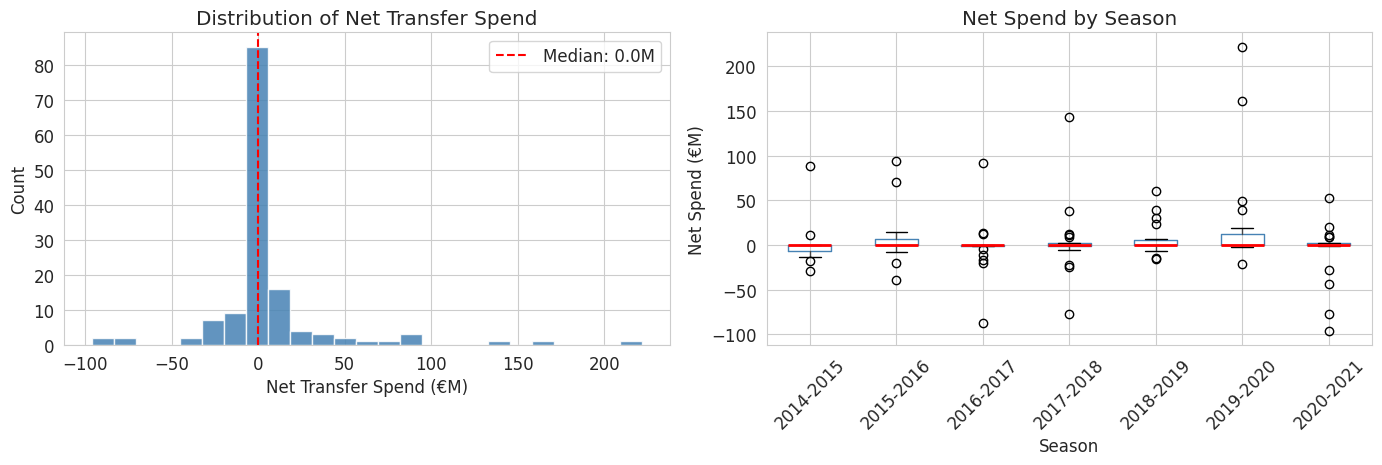


Median net spend: €0.0M
Most spent in a single season: €222.0M (Real Madrid 2019-2020)


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_merged['net_spend_m'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_merged['net_spend_m'].median(), color='red', linestyle='--', linewidth=1.5,
                label=f"Median: {df_merged['net_spend_m'].median():.1f}M")
axes[0].set_xlabel('Net Transfer Spend (€M)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Net Transfer Spend')
axes[0].legend()

# Boxplot by season
season_order = sorted(df_merged['season'].unique())
df_merged.boxplot(column='net_spend_m', by='season', ax=axes[1],
                  boxprops=dict(color='steelblue'),
                  medianprops=dict(color='red', linewidth=2))
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Net Spend (€M)')
axes[1].set_title('Net Spend by Season')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/eda_spend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMedian net spend: €{df_merged['net_spend_m'].median():.1f}M")
print(f"Most spent in a single season: €{df_merged['net_spend_m'].max():.1f}M "
      f"({df_merged.loc[df_merged['net_spend_m'].idxmax(), 'team']} "
      f"{df_merged.loc[df_merged['net_spend_m'].idxmax(), 'season']})")


### 5.2 Distribution of Final Points

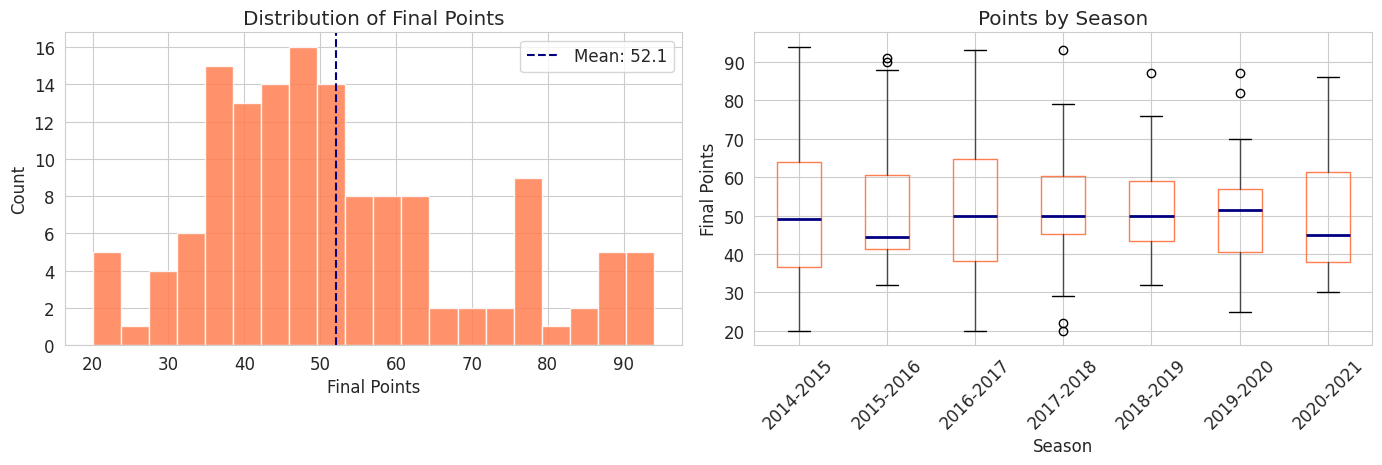

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_merged['pts'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(df_merged['pts'].mean(), color='navy', linestyle='--', linewidth=1.5,
                label=f"Mean: {df_merged['pts'].mean():.1f}")
axes[0].set_xlabel('Final Points')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Final Points')
axes[0].legend()

df_merged.boxplot(column='pts', by='season', ax=axes[1],
                  boxprops=dict(color='coral'),
                  medianprops=dict(color='navy', linewidth=2))
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Final Points')
axes[1].set_title('Points by Season')
plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/eda_points_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.3 Net Spend vs. Final Points

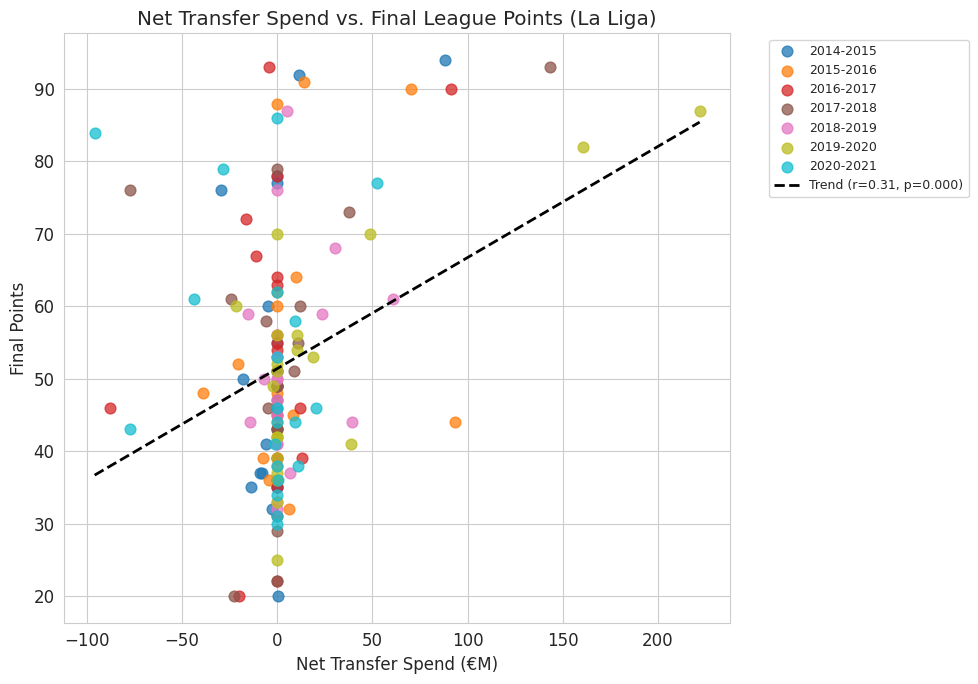

Pearson r = 0.310, p-value = 0.0002


In [38]:
fig, ax = plt.subplots(figsize=(10, 7))

seasons = sorted(df_merged['season'].unique())
colors = plt.cm.tab10(np.linspace(0, 1, len(seasons)))
color_map = dict(zip(seasons, colors))

for season in seasons:
    subset = df_merged[df_merged['season'] == season]
    ax.scatter(subset['net_spend_m'], subset['pts'],
               label=season, alpha=0.75, s=60,
               color=color_map[season])

# Overall trend line
m, b, r, p, se = stats.linregress(df_merged['net_spend_m'], df_merged['pts'])
x_line = np.linspace(df_merged['net_spend_m'].min(), df_merged['net_spend_m'].max(), 100)
ax.plot(x_line, m * x_line + b, color='black', linewidth=2, linestyle='--',
        label=f'Trend (r={r:.2f}, p={p:.3f})')

ax.set_xlabel('Net Transfer Spend (€M)')
ax.set_ylabel('Final Points')
ax.set_title('Net Transfer Spend vs. Final League Points (La Liga)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('data/eda_spend_vs_points.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Pearson r = {r:.3f}, p-value = {p:.4f}")


### 5.4 Top 5 Spenders vs. Bottom 5 Over Time

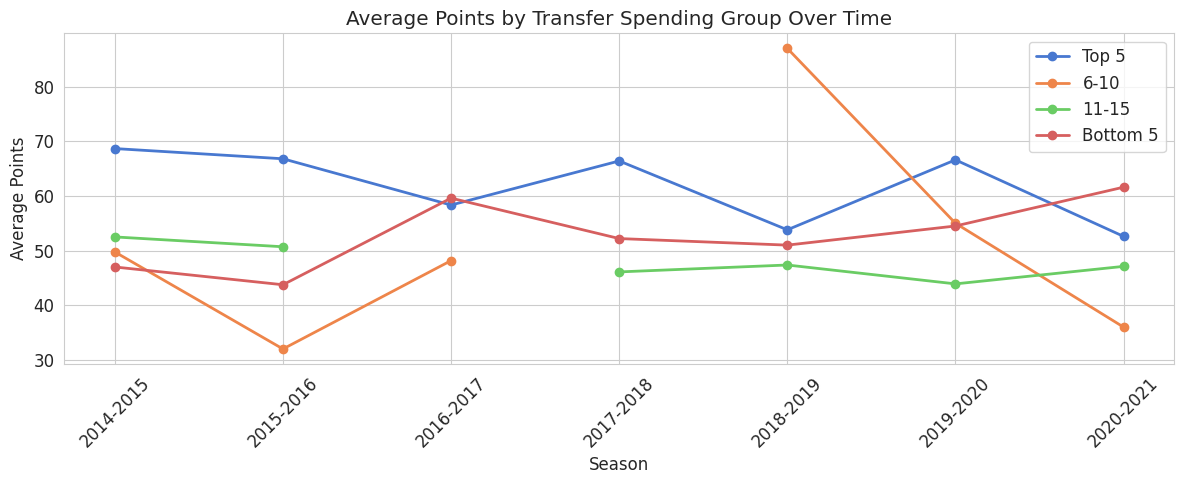

In [39]:
# Average points by spending rank group across seasons
df_merged['spend_rank'] = df_merged.groupby('season')['net_spend_m'].rank(ascending=False)
df_merged['spend_group'] = pd.cut(df_merged['spend_rank'], bins=[0, 5, 10, 15, 20],
                                   labels=['Top 5', '6-10', '11-15', 'Bottom 5'])

group_avg = df_merged.groupby(['season', 'spend_group'])['pts'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for group in ['Top 5', '6-10', '11-15', 'Bottom 5']:
    subset = group_avg[group_avg['spend_group'] == group]
    ax.plot(subset['season'], subset['pts'], marker='o', label=group, linewidth=2)

ax.set_xlabel('Season')
ax.set_ylabel('Average Points')
ax.set_title('Average Points by Transfer Spending Group Over Time')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('data/eda_spending_groups.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 Correlation Matrix

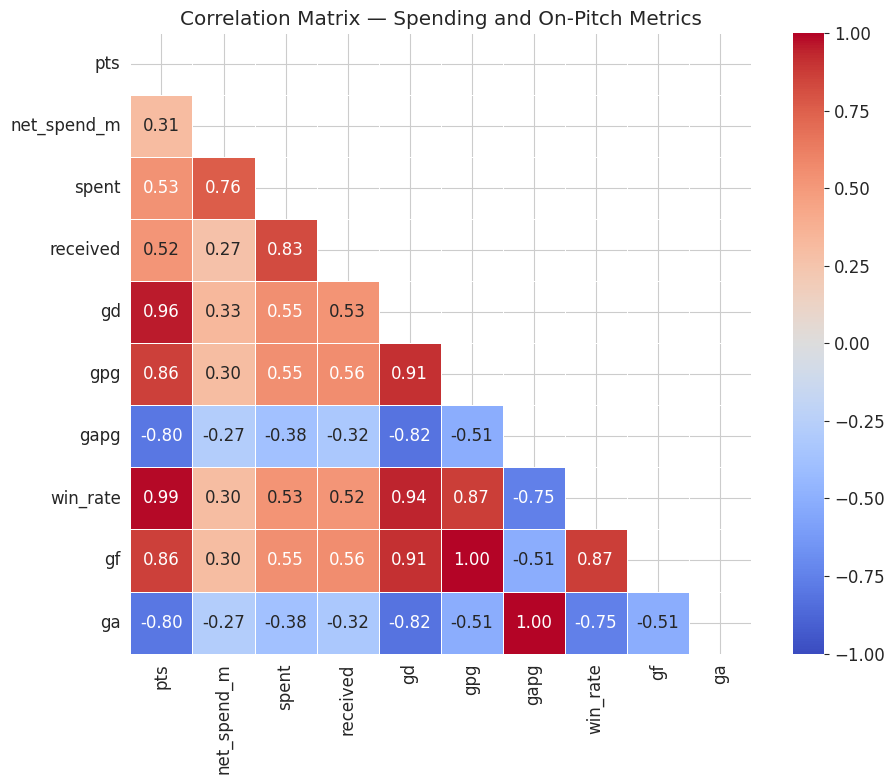


Features ranked by correlation with final points:
win_rate       0.989
gd             0.957
gpg            0.860
gf             0.860
gapg           0.801
ga             0.801
spent          0.532
received       0.523
net_spend_m    0.310
Name: pts, dtype: float64


In [40]:
corr_cols = ['pts', 'net_spend_m', 'spent', 'received',
             'gd', 'gpg', 'gapg', 'win_rate', 'gf', 'ga']
corr_matrix = df_merged[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, mask=mask,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Spending and On-Pitch Metrics')
plt.tight_layout()
plt.savefig('data/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Show all correlations with points, ranked
print("\nFeatures ranked by correlation with final points:")
print(corr_matrix['pts'].drop('pts').abs().sort_values(ascending=False).round(3))

### 5.6 Outlier Analysis — Who Over/Underperformed?

In [41]:
# Fit a simple linear regression of pts ~ net_spend_m
from numpy.polynomial.polynomial import polyfit

x = df_merged['net_spend_m'].values
y = df_merged['pts'].values

slope, intercept = np.polyfit(x, y, 1)
df_merged['pts_expected'] = slope * x + intercept
df_merged['residual'] = df_merged['pts'] - df_merged['pts_expected']

# Top overperformers (more points than expected given spend)
print("=== Biggest Overperformers (got more points than their spend suggested) ===")
print(df_merged.nlargest(5, 'residual')[['team', 'season', 'net_spend_m', 'pts', 'residual']].to_string(index=False))

print("\n=== Biggest Underperformers (got fewer points than their spend suggested) ===")
print(df_merged.nsmallest(5, 'residual')[['team', 'season', 'net_spend_m', 'pts', 'residual']].to_string(index=False))


=== Biggest Overperformers (got more points than their spend suggested) ===
       team    season  net_spend_m  pts  residual
Real Madrid 2020-2021        -96.0   84 47.315819
Real Madrid 2016-2017         -4.5   93 42.288359
Real Madrid 2014-2015         11.5   92 38.835469
  Barcelona 2015-2016         14.0   91 37.452205
 Ath Madrid 2015-2016          0.0   88 36.598484

=== Biggest Underperformers (got fewer points than their spend suggested) ===
      team    season  net_spend_m  pts   residual
   Cordoba 2014-2015         0.25   20 -31.439843
   Osasuna 2016-2017         0.00   22 -29.401516
Las Palmas 2017-2018         0.00   22 -29.401516
   Granada 2016-2017       -19.92   20 -28.347669
    Malaga 2017-2018       -22.50   20 -27.952141


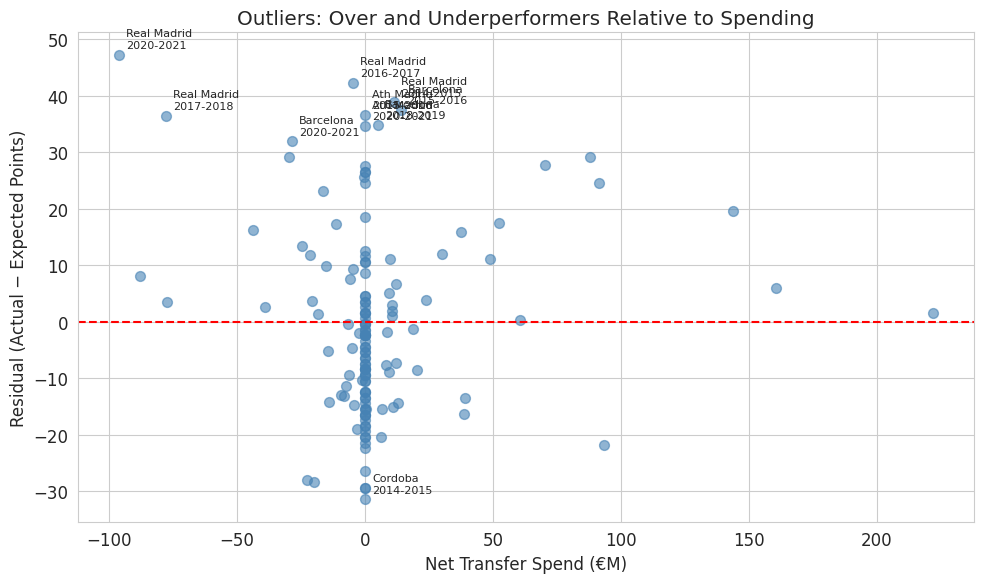

In [42]:
# Plot residuals
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_merged['net_spend_m'], df_merged['residual'], alpha=0.6, color='steelblue', s=50)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)

# Label extreme outliers
threshold = df_merged['residual'].std() * 1.8
for _, row in df_merged[abs(df_merged['residual']) > threshold].iterrows():
    ax.annotate(f"{row['team']}\n{row['season']}",
                xy=(row['net_spend_m'], row['residual']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

ax.set_xlabel('Net Transfer Spend (€M)')
ax.set_ylabel('Residual (Actual − Expected Points)')
ax.set_title('Outliers: Over and Underperformers Relative to Spending')
plt.tight_layout()
plt.savefig('data/eda_outliers.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Hypothesis Testing

**H₀:** There is no statistically significant correlation between a club's net transfer spend and its final points total in La Liga (ρ = 0).

**H₁:** Clubs with higher net transfer spend achieve significantly more points (ρ ≠ 0).

We use two tests:
1. **Spearman rank correlation** — measures monotonic relationship without assuming normality
2. **Mann-Whitney U test** — compares points distributions of top vs. bottom spending halves


### 6.1 Spearman Rank Correlation

In [43]:
rho, p_value = stats.spearmanr(df_merged['net_spend_m'], df_merged['pts'])

print("=" * 45)
print("Spearman Rank Correlation Test")
print("=" * 45)
print(f"  ρ (Spearman's rho) : {rho:.4f}")
print(f"  p-value            : {p_value:.4f}")
print(f"  n                  : {len(df_merged)}")
print()
alpha = 0.05
if p_value < alpha:
    print(f"  Result: p < {alpha} → Reject H₀")
    print("  There IS a statistically significant correlation between")
    print("  net transfer spend and final points.")
else:
    print(f"  Result: p >= {alpha} → Fail to reject H₀")
    print("  There is NO statistically significant correlation at the 5% level.")


Spearman Rank Correlation Test
  ρ (Spearman's rho) : 0.1550
  p-value            : 0.0675
  n                  : 140

  Result: p >= 0.05 → Fail to reject H₀
  There is NO statistically significant correlation at the 5% level.


### 6.2 Mann-Whitney U Test — Top vs. Bottom Spenders

In [44]:
# Split into top half and bottom half spenders within each season
df_merged['spend_half'] = df_merged.groupby('season')['net_spend_m'].transform(
    lambda x: pd.qcut(x, q=2, labels=['Bottom Half', 'Top Half'])
)

top_pts    = df_merged[df_merged['spend_half'] == 'Top Half']['pts']
bottom_pts = df_merged[df_merged['spend_half'] == 'Bottom Half']['pts']

u_stat, p_mw = stats.mannwhitneyu(top_pts, bottom_pts, alternative='greater')

print("=" * 45)
print("Mann-Whitney U Test")
print("H₀: Points distribution is the same for top and bottom spenders")
print("H₁: Top spenders have higher points (one-sided)")
print("=" * 45)
print(f"  U statistic        : {u_stat:.1f}")
print(f"  p-value            : {p_mw:.4f}")
print(f"  Top half mean pts  : {top_pts.mean():.1f}")
print(f"  Bottom half mean pts: {bottom_pts.mean():.1f}")
print(f"  Difference         : {top_pts.mean() - bottom_pts.mean():.1f} points")
print()
if p_mw < 0.05:
    print("  Result: p < 0.05 → Top spenders finish with significantly more points.")
else:
    print("  Result: p >= 0.05 → No significant difference at the 5% level.")


Mann-Whitney U Test
H₀: Points distribution is the same for top and bottom spenders
H₁: Top spenders have higher points (one-sided)
  U statistic        : 2479.5
  p-value            : 0.0019
  Top half mean pts  : 60.5
  Bottom half mean pts: 49.2
  Difference         : 11.2 points

  Result: p < 0.05 → Top spenders finish with significantly more points.


In [45]:
# Additional hypothesis test: does goal difference correlate with points?
rho_gd, p_gd = stats.spearmanr(df_merged['gd'], df_merged['pts'])
rho_wr, p_wr = stats.spearmanr(df_merged['win_rate'], df_merged['pts'])

print("=" * 50)
print("On-Pitch Metric Correlations with Final Points")
print("=" * 50)
print(f"  Goal Difference  : ρ = {rho_gd:.4f}, p = {p_gd:.4g}")
print(f"  Win Rate         : ρ = {rho_wr:.4f}, p = {p_wr:.4g}")
print("\nThese will be compared against transfer spending in the ML stage")
print("to determine whether financial or on-pitch factors are stronger predictors.")

On-Pitch Metric Correlations with Final Points
  Goal Difference  : ρ = 0.9439, p = 2.709e-68
  Win Rate         : ρ = 0.9843, p = 7.979e-106

These will be compared against transfer spending in the ML stage
to determine whether financial or on-pitch factors are stronger predictors.


## 7. Summary of Findings

| Test | Statistic | p-value | Conclusion |
|------|-----------|---------|------------|
| Spearman Correlation (ρ) | — | — | See output above |
| Mann-Whitney U | — | — | See output above |

**Key takeaways from EDA:**
- Net transfer spend is right-skewed — a small number of clubs (primarily Barcelona and Real Madrid) account for the majority of total spending.
- There is a visible positive trend between spending and points, but with significant variance — some clubs consistently over or underperform their budgets.
- Top spenders on average do finish with more points, but the relationship is not deterministic.

**Next steps (Stage 2):** Apply ML methods — Random Forest and Ridge Regression — to predict final points from transfer spend and on-pitch performance metrics, and extract feature importance to identify which variables matter most.


In [46]:
summary = pd.DataFrame({
    'Test': ['Spearman: net_spend vs pts',
             'Spearman: goal_difference vs pts',
             'Spearman: win_rate vs pts',
             'Mann-Whitney U: top vs bottom spenders'],
    'Statistic': [f'ρ = {rho:.3f}',
                  f'ρ = {rho_gd:.3f}',
                  f'ρ = {rho_wr:.3f}',
                  f'U = {u_stat:.0f}'],
    'p-value': [f'{p_value:.4f}',
                f'{p_gd:.4g}',
                f'{p_wr:.4g}',
                f'{p_mw:.4f}'],
    'Conclusion': [
        'Reject H₀' if p_value < 0.05 else 'Fail to reject H₀',
        'Reject H₀' if p_gd < 0.05    else 'Fail to reject H₀',
        'Reject H₀' if p_wr < 0.05    else 'Fail to reject H₀',
        'Reject H₀' if p_mw < 0.05    else 'Fail to reject H₀'
    ]
})
print(summary.to_string(index=False))
summary.to_csv('data/hypothesis_summary.csv', index=False)


                                  Test Statistic    p-value        Conclusion
            Spearman: net_spend vs pts ρ = 0.155     0.0675 Fail to reject H₀
      Spearman: goal_difference vs pts ρ = 0.944  2.709e-68         Reject H₀
             Spearman: win_rate vs pts ρ = 0.984 7.979e-106         Reject H₀
Mann-Whitney U: top vs bottom spenders  U = 2480     0.0019         Reject H₀
